# Estudio Dietary Data

## Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "C:\Users\Usuario\anaconda3\Lib\si

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "C:\Users\Usuario\anaconda3\Lib\si

AttributeError: _ARRAY_API not found

In [2]:
# Cargar el dataset
path = 'data/merged_sets/dietary_data.csv'
df_exam = pd.read_csv(path)

# Descartar el identificador SEQN
if 'SEQN' in df_exam.columns:
    df_exam = df_exam.drop(columns=['SEQN'])
    print("Columna 'SEQN' eliminada correctamente.")

# 1. Qué tipo de variables tenemos
print("--- Estructura del Dataset ---")
print(df_exam.info())

print("\n--- Conteo de tipos de datos ---")
print(df_exam.dtypes.value_counts())

# Separación sugerida para análisis
numeric_cols = df_exam.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_exam.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nVariables Numéricas ({len(numeric_cols)}): {numeric_cols[:5]}...") # Mostramos solo las primeras 5
print(f"Variables Categóricas ({len(categorical_cols)}): {categorical_cols}")

Columna 'SEQN' eliminada correctamente.
--- Estructura del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 8860 entries, 0 to 8859
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   WTDRD1    8860 non-null   float64
 1   DSDCOUNT  6754 non-null   float64
 2   DSDANCNT  6728 non-null   float64
 3   DSD010    6754 non-null   float64
 4   DSD010AN  6728 non-null   float64
dtypes: float64(5)
memory usage: 346.2 KB
None

--- Conteo de tipos de datos ---
float64    5
Name: count, dtype: int64

Variables Numéricas (5): ['WTDRD1', 'DSDCOUNT', 'DSDANCNT', 'DSD010', 'DSD010AN']...
Variables Categóricas (0): []


--- Columnas con valores faltantes ---
          Nulos  Porcentaje (%)
DSDANCNT   2132       24.063205
DSD010AN   2132       24.063205
DSDCOUNT   2106       23.769752
DSD010     2106       23.769752


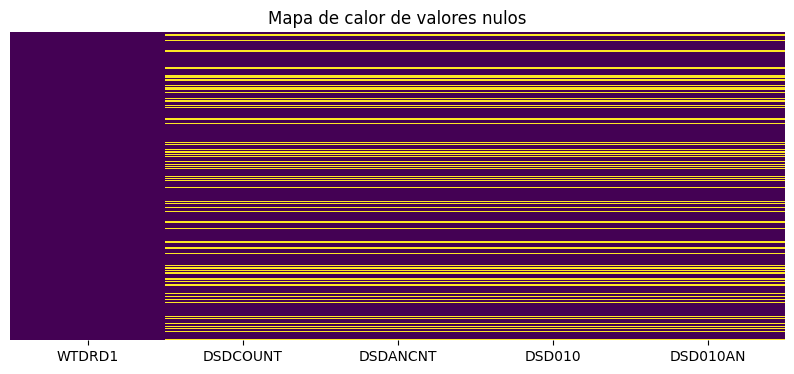

In [3]:
# 2. Análisis de nulos
null_count = df_exam.isnull().sum()
null_percentage = (null_count / len(df_exam)) * 100

null_df = pd.DataFrame({
    'Nulos': null_count,
    'Porcentaje (%)': null_percentage
}).sort_values(by='Nulos', ascending=False)

# Mostrar solo las columnas que tienen nulos
print("--- Columnas con valores faltantes ---")
print(null_df[null_df['Nulos'] > 0])

# Visualización rápida de nulos
plt.figure(figsize=(10, 4))
sns.heatmap(df_exam.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos')
plt.show()

--- Resumen de Outliers en el Dataset ---


,Columna,Outliers,Porcentaje (%)
2,DSDANCNT,884,9.98
4,DSD010AN,884,9.98
0,WTDRD1,465,5.25
1,DSDCOUNT,432,4.88
3,DSD010,23,0.26


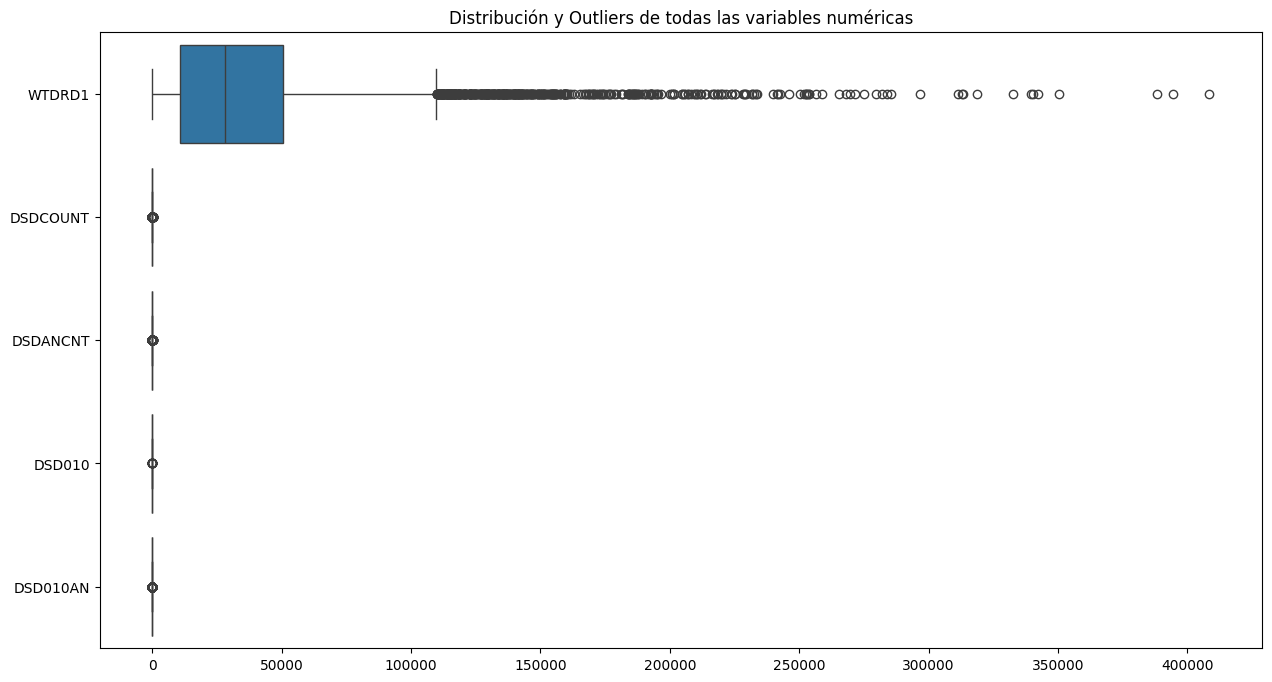

In [4]:
# 2. Análisis de Outliers
outliers_summary = []

for col in numeric_cols:
    Q1 = df_exam[col].quantile(0.25)
    Q3 = df_exam[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Contar cuántos valores están fuera de los límites
    num_outliers = df_exam[(df_exam[col] < lower_bound) | (df_exam[col] > upper_bound)].shape[0]
    perc_outliers = (num_outliers / len(df_exam)) * 100
    
    outliers_summary.append({
        'Columna': col,
        'Outliers': num_outliers,
        'Porcentaje (%)': round(perc_outliers, 2)
    })

# Convertir a DataFrame para visualizar mejor
df_outliers = pd.DataFrame(outliers_summary).sort_values(by='Outliers', ascending=False)
print("--- Resumen de Outliers en el Dataset ---")
display(df_outliers)

# Visualización general (Boxplot de todas las variables normalizadas para comparar)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_exam[numeric_cols], orient="h")
plt.title("Distribución y Outliers de todas las variables numéricas")
plt.show()

--- Estadísticos Principales ---


,WTDRD1,DSDCOUNT,DSDANCNT,DSD010,DSD010AN
count,8.860000e+03,6.754000e+03,6.728000e+03,6754.000000,6728.000000
mean,3.690898e+04,1.844389e+00,2.430143e-01,1.462985,1.877229
std,3.999623e+04,5.499370e+00,3.164713e+00,0.623975,0.403381
min,5.397605e-79,5.397605e-79,5.397605e-79,1.000000,1.000000
25%,1.075696e+04,5.397605e-79,5.397605e-79,1.000000,2.000000
50%,2.804253e+04,1.000000e+00,5.397605e-79,1.000000,2.000000
75%,5.040740e+04,2.000000e+00,5.397605e-79,2.000000,2.000000
max,4.085058e+05,9.900000e+01,9.900000e+01,9.000000,9.000000


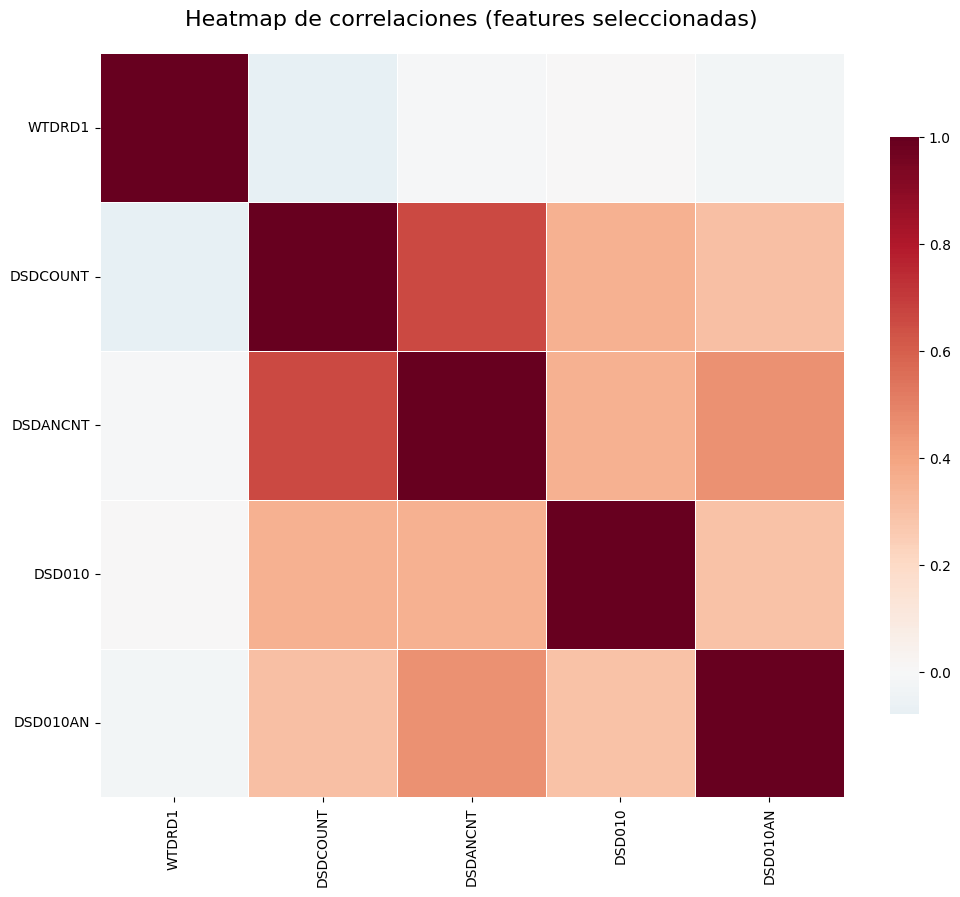


--- Parejas de variables con mayor correlación positiva ---


DSDCOUNT  DSDANCNT    0.655669
DSDANCNT  DSD010AN    0.455510
          DSD010      0.352082
DSDCOUNT  DSD010      0.352078
          DSD010AN    0.297246
dtype: float64


--- Parejas de variables con mayor correlación negativa ---


DSD010AN  WTDRD1     NaN
          DSDCOUNT   NaN
          DSDANCNT   NaN
          DSD010     NaN
          DSD010AN   NaN
dtype: float64

In [7]:
# 3. Análisis Estadístico Descriptivo
print("--- Estadísticos Principales ---")
display(df_exam.describe())

# 4. Visualización de correlación 
# Calculamos la matriz
corr_matrix = df_exam[numeric_cols].corr()

# Configuramos el tamaño de la figura
plt.figure(figsize=(12, 10))

# Dibujamos el heatmap 
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='RdBu_r', 
            center=0,
            linewidths=.5, 
            linecolor='white',
            square=True,
            cbar_kws={"shrink": .75})

# Ajustes de etiquetas y título
plt.title("Heatmap de correlaciones (features seleccionadas)", fontsize=16, pad=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

# Ranking de correlaciones (para no perder el dato exacto del Top 5)
sol = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(ascending=False))

print("\n--- Parejas de variables con mayor correlación positiva ---")
display(sol.head(5))

print("\n--- Parejas de variables con mayor correlación negativa ---")
display(sol.tail(5))